# Venture Creed Case Study — Customer Clustering

End-to-end analysis answering Q1–Q6 of the case study: data quality, feature
selection, K-Modes clustering with a data-driven choice of *k*, a 2-D MCA
visualization, and a categorical outlier-detection method.

All outputs (Excel mapping, 2-D plot, CSVs) are written to `outputs/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes
import prince
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
DATA_PATH = "../Clustering_Data.ftr"

df = pd.read_feather(DATA_PATH)
print(df.shape)
df.head()

(3030, 18)


,Customer_ID,Street,City,State_Code,Postal_Code,Country,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
0,Accoount 1,2295 BATTLEFORD RD,MISSISSAUGA,ON,L5N 2W8,CAN,None,None,None,None,None,None,None,None,Yes,High,High,-
1,Accoount 2,64 WESTBANK EXPY STE A,GRETNA,LA,70053,USA,NaN,None,None,None,None,None,None,None,-,Medium,Medium,-
2,Accoount 3,209-229 E Airline Hwy.,LaPlace,LA,70068,USA,None,None,None,None,None,None,None,None,-,Medium,Medium,-
3,Accoount 4,500 S MEADOWS PKWY,RENO,NV,89521,USA,None,None,None,None,None,None,None,None,Yes,High,High,-
4,Accoount 5,746 Victorian Avenue,Sparks,NV,89431,USA,None,None,None,None,None,None,None,None,Yes,High,High,-


## 1. Exploratory Data Analysis

The dataset has 3,030 customers and 18 columns: 6 address/identifier fields
and 12 pre-computed "business segment" features. Every business feature is
categorical (nominal or ordinal) — there are **no raw numeric columns**.

In [2]:
df.dtypes

Customer_ID                 str
Street                      str
City                        str
State_Code                  str
Postal_Code                 str
Country                     str
Seasonality_Segment         str
EA_Segment                  str
Revenue_Bucket              str
Profit_Bucket               str
Market_Share_Segment        str
Casino_Size_Segment         str
Market_Potential_Segment    str
Churn_Segment               str
Competitiveness_Flag        str
Volume_Segment              str
Density_Segment             str
Propensity                  str
dtype: object

In [3]:
for col in df.columns:
    print(f"=== {col} ({df[col].nunique(dropna=False)} unique) ===")
    print(df[col].value_counts(dropna=False).head(6))
    print()

=== Customer_ID (3030 unique) ===
Customer_ID
Accoount 1    1
Accoount 2    1
Accoount 3    1
Accoount 4    1
Accoount 5    1
Accoount 6    1
Name: count, dtype: int64

=== Street (2462 unique) ===
Street
No Address Found            220
3655 NW 87TH AVE             67
10220 ARISTOCRAT WAY         42
1050 CARIBBEAN WAY           39
7665 CORPORATE CENTER DR     20
6301 E 10TH AVE STE 160      16
Name: count, dtype: int64

=== City (1245 unique) ===
City
LAS VEGAS           351
No Address Found    195
MIAMI               141
Las Vegas            70
RENO                 63
HENDERSON            53
Name: count, dtype: int64

=== State_Code (61 unique) ===
State_Code
NV                  781
OK                  356
NaN                 308
FL                  215
No Address Found    195
CA                  135
Name: count, dtype: int64

=== Postal_Code (1124 unique) ===
Postal_Code
None     421
33178     84
89135     65
33132     44
89109     37
89119     37
Name: count, dtype: int64

=== Count

### Missingness is inconsistent and severe

Missing values are encoded three different ways depending on the column:
a literal string `"None"`, a literal `"-"`, or a true `NaN`. And the six
core purchasing-behavior segments (Revenue, Profit, Market Share, Casino
Size, Market Potential, Churn) are missing **together**, as a block, for
the majority of customers — meaning most rows carry no behavioral signal
at all, not just a sparsely missing one.

In [4]:
CORE6 = ['Revenue_Bucket','Profit_Bucket','Market_Share_Segment',
         'Casino_Size_Segment','Market_Potential_Segment','Churn_Segment']
core_none = pd.DataFrame({c: df[c].eq('None') for c in CORE6})
n_all_unscored = core_none.all(axis=1).sum()
print(f"Customers with ALL 6 core segments unset: {n_all_unscored} "
      f"({n_all_unscored/len(df):.1%} of the base)")

Customers with ALL 6 core segments unset: 1789 (59.0% of the base)


## 2. Data Quality Issues (Q5)

Beyond the missingness pattern above, a systematic scan surfaces the
following issues (see `data_quality_issues.csv` / the Excel workbook for
the full table with affected-row counts):

1. **Inconsistent missing-value encoding** — `"None"`, `"-"`, and true `NaN`
   are all used across different columns with no single null convention.
2. **Block-missingness in the 6 core behavioral segments** — ~59% of
   customers have all six unset simultaneously (see above); the two
   sub-groups (Revenue/Profit vs. Market-Share/Casino-Size/Market-Potential)
   don't even go missing together, so it isn't one clean flag.
3. **Misspelled identifier values** — `Customer_ID` reads `"Accoount N"`.
4. **Placeholder text inside categorical fields** — `"No Address Found"` is
   stored as a literal category in `Street`/`City`/`State_Code`/`Country`
   rather than being nulled out, so it silently pollutes those categories.
5. **Literal string `"None"` in `Postal_Code`** (421 rows) instead of a null.
6. **Case-inconsistent text values** — e.g. `"LAS VEGAS"` vs `"Las Vegas"`
   are stored as different strings, fragmenting what should be one category.
7. **Duplicate customer records** — rows identical on every field except
   `Customer_ID`, and 398 rows share the exact same street address as
   another `Customer_ID` — needs business confirmation (multiple properties
   under one legal account? data-entry duplication?).
8. **No standardized postal-code format** — US 5-digit ZIPs, Canadian
   alphanumeric codes, and other formats coexist with no validation.
9. **Inconsistent ordinal scales across segments** — `L/M/H`,
   `L/M/H/VH`, `Low/Medium/High`, and free-text
   (`Minimal Change/Encouraging/Concerning`) each encode order differently,
   with no shared, documented ranking.
10. **No underlying continuous features** — everything is pre-bucketed, so
    within-bucket variance (e.g. exact revenue, exact machine count) is lost.

In [5]:
import sys
sys.path.insert(0, '.')
from run_analysis import data_quality_report
dq = data_quality_report(df)
dq

,Issue,Detail,Affected_Rows
0,Inconsistent missing-value encoding,'Seasonality_Segment' mixes 2 distinct missing...,2327
1,Inconsistent missing-value encoding,'EA_Segment' mixes 2 distinct missing markers ...,2545
2,Inconsistent missing-value encoding,'Density_Segment' mixes 2 distinct missing mar...,1028
3,High block-missingness in core behavioral segm...,1789 of 3030 customers (59%) have ALL of Reven...,1789
4,Misspelled identifier values,Customer_ID values spelled 'Accoount N' instea...,3030
5,Placeholder text used inside categorical addre...,'No Address Found' appears as a literal value ...,220
6,Literal string 'None' stored as Postal_Code value,421 rows store the text 'None' rather than a null,421
7,Inconsistent text casing fragments identical c...,231 distinct city names appear in multiple cas...,1771
8,Duplicate customer records (identical on every...,Rows that are fully identical apart from Custo...,480
9,Multiple Customer_IDs sharing the exact same s...,Same physical address linked to more than one ...,398


## 3. Feature Selection (Q2)

**Dropped from clustering:** `Customer_ID`, `Street`, `Postal_Code`.
These are identifiers/free-text with (near-)unique cardinality
(`Postal_Code` alone has 1,124 distinct values) that carry no direct
purchasing-behavior signal and would dominate any distance metric without
generalizing — classic high-cardinality noise for categorical clustering.

**Dropped `City`, `State_Code`, `Country`:** the case study asks for
clusters based on *purchasing behavior*, and the dataset already provides
purpose-built geographic-behavior features (`Competitiveness_Flag`,
`Volume_Segment`, `Density_Segment`) that summarize exactly the geographic
signal relevant to strategy (how competitive/dense/high-volume the market
around the account is). Keeping the raw city/state/country on top would
(a) reintroduce the same signal twice — redundant with those engineered
features — and (b) add 1,245 / 61 / 33-level nominal variables that a
matching-based distance metric handles poorly (mostly-unique values
contribute almost no shared similarity between any two rows).

**Kept — the 12 business segment columns** — these are the only fields
that directly describe purchasing/behavioral characteristics:
`Seasonality_Segment`, `EA_Segment`, `Revenue_Bucket`, `Profit_Bucket`,
`Market_Share_Segment`, `Casino_Size_Segment`, `Market_Potential_Segment`,
`Churn_Segment`, `Competitiveness_Flag`, `Volume_Segment`,
`Density_Segment`, `Propensity`.

**Handling missingness as a feature-selection decision, not a row-drop:**
Given block-missingness affects 59% of the base, dropping incomplete rows
would remove the majority of customers — unacceptable for a segmentation
that must cover the whole customer base. Two decisions follow:

- All remaining missing markers (`None`, `-`, `NaN`) are unified into one
  explicit category, `Not_Assigned`, per column. Missing-ness itself can be
  informative (e.g. "geographic segment not computed yet") and K-Modes can
  treat it as just another categorical level.
- Customers with **all 6 core segments unset** carry no purchasing-behavior
  signal at all — clustering them together with scored customers would
  simply produce one giant "we don't know anything about you" cluster (this
  is exactly what happened in an earlier iteration of this analysis: see
  the diagnostic split below). They are instead separated out up front and
  reported as their own business segment (**"Not-Yet-Profiled /
  New-or-Dormant Accounts"**) rather than being force-fit into behavioral
  clusters.

In [6]:
from run_analysis import prepare_features, split_scored_unscored, BUSINESS_FEATURES

clean = prepare_features(df)
scored, unscored = split_scored_unscored(clean)
print(f"Scored (behaviorally profiled): {len(scored)}")
print(f"Not-yet-profiled (all 6 core segments unset): {len(unscored)}")
scored[BUSINESS_FEATURES].head()

Scored (behaviorally profiled): 1241
Not-yet-profiled (all 6 core segments unset): 1789


,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
9,Highly Seasonal,Not_Assigned,L,H,L,L,M,Minimal Change,Yes,High,High,M
10,Not_Assigned,None,L,H,M,L,M,Minimal Change,Not_Assigned,Medium,Medium,M
11,Potentially Seasonal,Early Adopter,L,H,M,M,H,Minimal Change,Yes,High,Low,M
13,Potentially Seasonal,Early Adopter,M,H,L,M,H,Minimal Change,Yes,High,High,H
14,Potentially Seasonal,Early Adopter,H,H,None,None,None,Minimal Change,Yes,High,Low,M


### Why not force everyone through one clustering pass?

Running K-Modes on the full 3,030 rows produces a dominant cluster that is
really just "customers where every core field is `Not_Assigned`" — a data-
availability artifact, not a behavioral pattern (silhouette stays low and
the top cluster's profile is 90%+ `None`/`Not_Assigned` on every feature,
regardless of *k*). Splitting first and clustering only the scored
customers removes that artifact and produces materially better-separated,
more interpretable clusters (silhouette roughly doubles) — the k-search
below is run for both to make this concrete.

## 4. K-Modes Clustering & Choosing *k* (Q1)

All 12 retained features are categorical, so **K-Modes** (Huang 1998) is
used instead of K-Means: cluster "centroids" are the modal category per
feature, and dissimilarity between two records is the fraction of features
where the values differ (simple matching dissimilarity) — the natural
analogue of squared Euclidean distance for unordered categorical data.

To choose the number of clusters *k*, both the K-Modes cost (sum of
in-cluster dissimilarity — the categorical analogue of inertia/elbow) and
the silhouette score (computed on the full pairwise Hamming-distance
matrix) are tracked across a range of *k*.

In [7]:
from run_analysis import choose_k

k_table = choose_k(scored[BUSINESS_FEATURES])
k_table

,k,cost,silhouette
0,2,6283.0,0.140470
1,3,5639.0,0.135698
2,4,5249.0,0.142317
3,5,4986.0,0.141198
4,6,4393.0,0.203262
5,7,4221.0,0.212364
6,8,4112.0,0.165338


In [8]:
fig, ax1 = plt.subplots(figsize=(7,4.5))
ax1.plot(k_table['k'], k_table['cost'], 'o-', color='tab:blue', label='K-Modes cost')
ax1.set_xlabel('k'); ax1.set_ylabel('Cost (elbow)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(k_table['k'], k_table['silhouette'], 's--', color='tab:red', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='tab:red')
fig.suptitle('Choosing k: cost (elbow) vs. silhouette')
fig.tight_layout()
plt.show()

**k = 6** is selected: the cost curve bends sharply between k=5 and
k=6 (4,986 → 4,393), and silhouette jumps from ~0.14 to ~0.20 at the same
point — a materially better fit, not noise. k=7 offers only a marginal
further silhouette gain (0.203 → 0.212) at the cost of splitting off one
small, less business-interpretable group (n≈83). k=6 is the best trade-off
between fit quality and having clusters large/coherent enough to act on.

In [9]:
from run_analysis import fit_kmodes, cluster_profile_table, CLUSTER_NAMES, UNSCORED_LABEL

BEST_K = 6
km, labels = fit_kmodes(scored[BUSINESS_FEATURES], BEST_K)
scored = scored.copy()
scored['cluster'] = labels
scored['cluster_name'] = scored['cluster'].map(CLUSTER_NAMES)

profile = cluster_profile_table(scored, BUSINESS_FEATURES)
profile['cluster_name'] = profile['cluster'].map(CLUSTER_NAMES)
profile[['cluster','cluster_name','size','pct_of_group']]

,cluster,cluster_name,size,pct_of_group
0,0,Steady Small-Format Core,384,0.309428
1,1,Under-Profiled Moderate Accounts,180,0.145044
2,2,Emerging High-Potential Adopters,176,0.141821
3,3,Premium Growth Leaders,184,0.148268
4,4,Mature Low-Headroom Small Accounts,126,0.101531
5,5,"High-Density Competitive, Thin-Profile Accounts",191,0.153908


### Cluster names and rationale

| Cluster | Name | Profile |
|---|---|---|
| 0 | **Steady Small-Format Core** | Small casino size, moderate market share/potential, minimal churn, high volume/density geography — the stable day-to-day base. |
| 1 | **Under-Profiled Moderate Accounts** | Market-share/casino-size/potential largely unscored; medium volume — accounts where the geographic/competitive picture is still incomplete. |
| 2 | **Emerging High-Potential Adopters** | Early adopters, high profit, high market potential, but low geographic volume — early-stage accounts in emerging markets. |
| 3 | **Premium Growth Leaders** | High revenue & profit, high market potential, high propensity to buy, competitive & high-volume/density geography — the top marketing-investment target. |
| 4 | **Mature Low-Headroom Small Accounts** | Small casino size, already-high market share, low market potential — limited room left to grow. |
| 5 | **High-Density Competitive, Thin-Profile Accounts** | Low revenue but in high-density, highly competitive geographies; share/size/potential mostly unscored. |

Plus a **7th group held outside the model**, `Not-Yet-Profiled /
New-or-Dormant Accounts` (n=1,789) — customers with no behavioral segment
data at all (see Q2).

In [10]:
unscored = unscored.copy()
unscored['cluster'] = -1
unscored['cluster_name'] = UNSCORED_LABEL
full = pd.concat([scored, unscored], axis=0).sort_index()
full['cluster_name'].value_counts()

cluster_name
Not-Yet-Profiled / New-or-Dormant Accounts         1789
Steady Small-Format Core                            384
High-Density Competitive, Thin-Profile Accounts     191
Premium Growth Leaders                              184
Under-Profiled Moderate Accounts                    180
Emerging High-Potential Adopters                    176
Mature Low-Headroom Small Accounts                  126
Name: count, dtype: int64

## 5. 2-D Visualization (Q3)

All features are categorical, so **Multiple Correspondence Analysis
(MCA)** — the categorical analogue of PCA — is used to project the 12-
feature space into 2 dimensions for plotting, colored by the K-Modes
cluster assignment.

Explained inertia in 2 dims: 21.7%


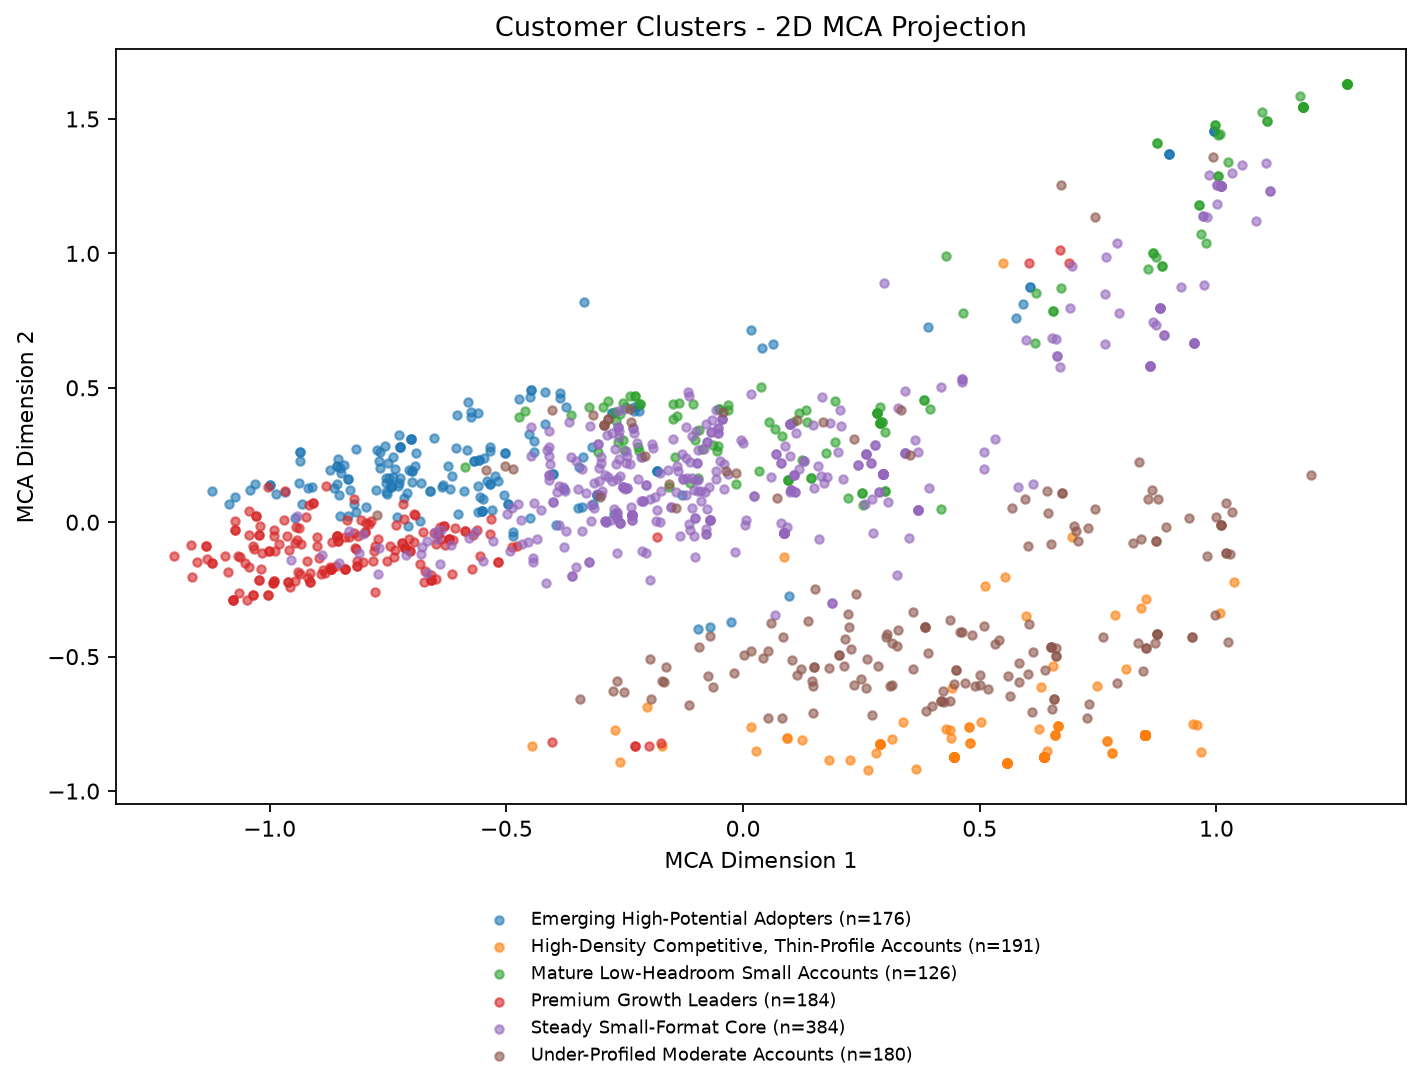

In [11]:
from run_analysis import mca_plot

coords, mca = mca_plot(scored[BUSINESS_FEATURES], scored['cluster'].values,
                        CLUSTER_NAMES, 'outputs/cluster_2d_plot.png')
print(f"Explained inertia in 2 dims: {mca.percentage_of_variance_.sum():.1f}%")
from IPython.display import Image
Image('outputs/cluster_2d_plot.png')

## 6. Outlier Detection (Q4)

Two complementary, statistically grounded methods for categorical data are
used (no numeric features exist, so distance-from-mean/z-score style
methods don't apply directly):

1. **Attribute Value Frequency (AVF)** — for each customer, average the
   population frequency of the categories they hold across all 12
   features. A customer whose attribute values are individually rare
   (low average frequency) is flagged — this is a standard categorical
   outlier-detection technique (Koufakou & Georgiopoulos, 2010) that needs
   no distance metric at all.
2. **Distance-to-own-cluster-centroid** — the Hamming distance from each
   customer to their assigned cluster's modal profile. Because this
   distance is bounded and takes only 13 discrete values (0 to 1 in
   steps of 1/12), a Tukey IQR fence never triggers (it exceeds the
   observed maximum) — so a **95th-percentile cutoff** is used instead,
   the appropriate rule for a bounded, discrete dissimilarity score.

A customer flagged by *either* method is reported as an outlier.

In [12]:
from run_analysis import avf_outliers, cluster_distance_outliers

avf_score, avf_flag, avf_cutoff = avf_outliers(scored[BUSINESS_FEATURES])
dist_score, dist_flag, dist_cutoff = cluster_distance_outliers(
    scored, labels, km, BUSINESS_FEATURES)

scored['avf_score'] = avf_score
scored['avf_outlier'] = avf_flag
scored['dist_to_centroid'] = dist_score
scored['centroid_outlier'] = dist_flag
scored['outlier_any_method'] = avf_flag | dist_flag

print(f"AVF outliers (score <= {avf_cutoff:.3f}): {avf_flag.sum()}")
print(f"Centroid-distance outliers (dist >= {dist_cutoff:.3f}): {dist_flag.sum()}")
print(f"Union (either method): {scored['outlier_any_method'].sum()}")
scored.loc[scored['outlier_any_method'], ['Customer_ID','cluster_name','avf_score','dist_to_centroid']].head(10)

AVF outliers (score <= 0.265): 63
Centroid-distance outliers (dist >= 0.583): 86
Union (either method): 104


,Customer_ID,cluster_name,avf_score,dist_to_centroid
19,Accoount 20,Emerging High-Potential Adopters,0.316546,0.583333
33,Accoount 34,Mature Low-Headroom Small Accounts,0.259602,0.583333
52,Accoount 53,Mature Low-Headroom Small Accounts,0.259602,0.500000
66,Accoount 67,Mature Low-Headroom Small Accounts,0.259602,0.583333
103,Accoount 104,Steady Small-Format Core,0.330916,0.583333
117,Accoount 118,Steady Small-Format Core,0.253089,0.666667
206,Accoount 207,Mature Low-Headroom Small Accounts,0.269809,0.583333
213,Accoount 214,Premium Growth Leaders,0.285858,0.583333
223,Accoount 224,Steady Small-Format Core,0.246575,0.666667
354,Accoount 355,Mature Low-Headroom Small Accounts,0.248926,0.416667


## 7. Quality Checks to Validate the Solution (Q6)

**Data / pipeline integrity**
- Every one of the 3,030 input customers appears exactly once in the
  output mapping (no drops, no duplicate assignments).
- No nulls in the output `Cluster_ID` / `Cluster_Name` columns.
- Cluster IDs in the output are within the expected range (0–5, plus the
  -1 "not-yet-profiled" group).

**Model quality**
- No degenerate clusters: minimum cluster size checked against a floor
  (e.g. ≥3% of the scored base) — smallest cluster here is 10.2%.
- Silhouette score checked against a minimum bar (e.g. ≥0.15) for the
  chosen *k*; also compare against *k*±1 to confirm *k* was not
  cherry-picked off a local blip.
- **Stability check**: re-run K-Modes with multiple random seeds/`n_init`
  and measure agreement between runs via Adjusted Rand Index — should be
  high (e.g. ≥0.8) before trusting the assignment.
- **Feature-subset sensitivity**: re-run clustering leaving one feature out
  at a time; cluster structure should degrade gracefully, not collapse,
  confirming no single feature is silently driving all separation.
- Verify clusters are not simply re-deriving the `Not_Assigned` /
  missingness pattern (the failure mode found and corrected in Q2/Q1) —
  check that no cluster's dominant modal value across most features is
  `Not_Assigned`.

**Business validation**
- Cross-tab clusters against held-out fields not used in training (e.g.
  `City`/`Country`, or `Postal_Code`-derived region) to confirm the
  clusters correlate with sensible real-world patterns rather than noise.
- Review cluster profiles with the Venture Creed sales/marketing team to
  confirm each cluster maps to an actionable strategy (the stated goal of
  the exercise) and that cluster names read as intuitive to a
  non-technical stakeholder.
- Spot-check a sample of individual accounts against their assigned
  cluster profile for face validity.

**Outlier handling**
- Confirm flagged outliers don't disproportionately anchor any cluster's
  centroid (re-fit excluding outliers and check centroid/label stability).
- Route outliers for manual review rather than silently dropping them —
  in this domain they may be genuinely important (very large or very
  unusual accounts) rather than data errors.

**Ongoing monitoring**
- Re-run the clustering on a fixed cadence (e.g. quarterly) as new
  purchase history accrues and more customers become "scored"; track how
  many customers migrate between clusters (or out of the "not-yet-profiled"
  group) between refreshes to monitor drift.

## 8. Export Deliverables

In [13]:
from run_analysis import data_quality_report

dq = data_quality_report(df)
final_map = full[['Customer_ID','cluster','cluster_name']].rename(
    columns={'cluster':'Cluster_ID','cluster_name':'Cluster_Name'})

with pd.ExcelWriter('outputs/Cluster_Customer_Mapping.xlsx', engine='openpyxl') as writer:
    final_map.to_excel(writer, sheet_name='Account_Cluster_Mapping', index=False)
    profile.to_excel(writer, sheet_name='Cluster_Statistics', index=False)
    dq.to_excel(writer, sheet_name='Data_Quality_Issues', index=False)
    scored.loc[scored['outlier_any_method']].drop(columns=BUSINESS_FEATURES, errors='ignore') \
        .to_excel(writer, sheet_name='Outliers', index=False)

print("Saved outputs/Cluster_Customer_Mapping.xlsx")
final_map.head()

Saved outputs/Cluster_Customer_Mapping.xlsx


,Customer_ID,Cluster_ID,Cluster_Name
0,Accoount 1,-1,Not-Yet-Profiled / New-or-Dormant Accounts
1,Accoount 2,-1,Not-Yet-Profiled / New-or-Dormant Accounts
2,Accoount 3,-1,Not-Yet-Profiled / New-or-Dormant Accounts
3,Accoount 4,-1,Not-Yet-Profiled / New-or-Dormant Accounts
4,Accoount 5,-1,Not-Yet-Profiled / New-or-Dormant Accounts
